## Linear Regression — Predicting Employee Salary from Experience

### Business Problem

An HR team at a mid-sized tech company wants to build a **compensation benchmarking tool**. Given a candidate's years of experience and role seniority, the model should estimate a fair market salary. This enables recruiters to make data-driven offers and flag internal pay inequities.

### Why Linear Regression?

The target variable (salary) is **continuous**, the relationship between experience and compensation is approximately linear, and interpretability is paramount — HR and legal stakeholders need to understand and defend every predicted value. Linear regression delivers a direct, auditable formula with no black-box behavior. Coefficient signs and magnitudes map directly to business intuition (e.g., "each additional year of experience adds $X to base salary").

In [11]:
from mistune.plugins.formatting import mark
from pyparsing import line, lineStart

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

=== Linear Regression: Salary Benchmarking ===
R² Score:              0.9371
Mean Absolute Error:   $6,640

Coefficients:
  years_experience      :   4,579.68
  seniority_level       :  14,326.24
  Intercept             :  45,207.29

Predicted salary (7 yrs exp, seniority 3): $120,244


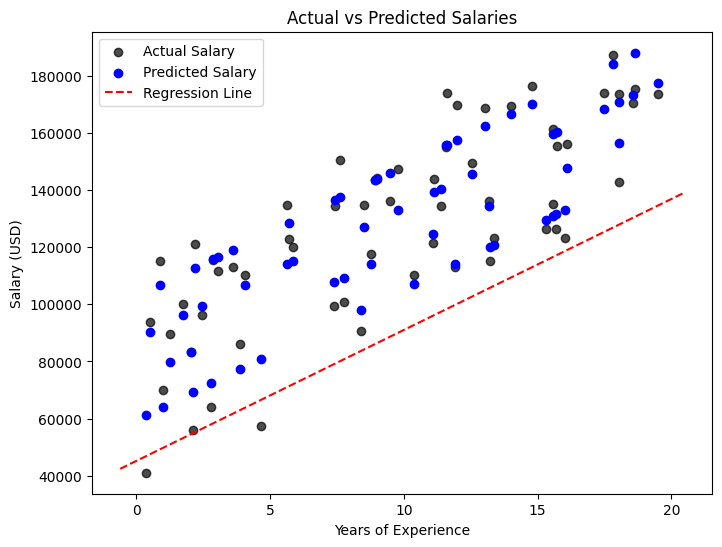

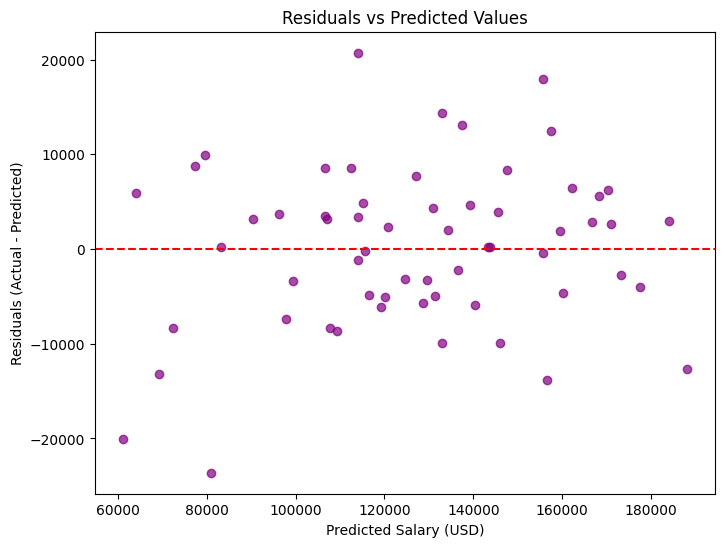

In [22]:
"""
Salary prediction using Linear Regression.

Business goal: Estimate fair market salary from years of experience
and seniority level for HR compensation benchmarking.
"""


def generate_salary_data(n_samples: int = 300, seed: int = 42) -> pd.DataFrame:
    """
    Generate synthetic employee compensation data.

    Args:
        n_samples: Number of records to generate.
        seed: Random seed for reproducibility.

    Returns:
        DataFrame with features and target salary column.
    """
    rng = np.random.default_rng(seed)
    years_experience = rng.uniform(0, 20, n_samples)
    seniority = rng.integers(1, 5, n_samples)  # 1=Junior, 4=Principal
    noise = rng.normal(0, 8_000, n_samples)

    # Linear form: y = b_0 + b_1*x_1 + b_2*x_2 + noise
    salary = 45_000 + (years_experience * 4_500) + (seniority * 15_000) + noise

    return pd.DataFrame(
        {
            "years_experience": years_experience,
            "seniority_level": seniority,
            "salary_usd": salary,
        }
    )


"""Train and evaluate salary prediction model."""
salary = generate_salary_data()
X = salary[["years_experience", "seniority_level"]]  # explanatory/predictor variables
y = salary["salary_usd"]  # response

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Options for feature scaling (uncomment if desired):
# scaler = StandardScaler()  # using z-score
# # Note: We find mu and sigma from the training set only, then apply to both train and test sets.
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)  # Regress salary on the two features

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression: Salary Benchmarking ===")
print(f"R² Score:              {r2:.4f}")
print(f"Mean Absolute Error:   ${mae:,.0f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_, strict=True):
    print(f"  {feature:<22}: {coef:>10,.2f}")
print(f"  {'Intercept':<22}: {model.intercept_:>10,.2f}")

# Predict for a new candidate
candidate = pd.DataFrame({"years_experience": [7.0], "seniority_level": [3]})
# candidate_scaled = scaler.transform(candidate)
prediction = model.predict(candidate)[0]
print(f"\nPredicted salary (7 yrs exp, seniority 3): ${prediction:,.0f}")


# Plot actual vs predicted salaries
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    X_test["years_experience"], y_test, alpha=0.7, color="black", label="Actual Salary"
)
ax.scatter(X_test["years_experience"], y_pred, color="blue", label="Predicted Salary")
x_lower, x_upper = ax.get_xlim()
y_lower = model.intercept_ + model.coef_[0] * x_lower
y_upper = model.intercept_ + model.coef_[0] * x_upper
ax.plot([x_lower, x_upper], [y_lower, y_upper], "r--", label="Regression Line")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary (USD)")
ax.set_title("Actual vs Predicted Salaries")
ax.legend()
plt.show()


# Let's also plot the fitted values versus the residuals to check for any patterns that might indicate model misspecification.
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_pred, residuals, alpha=0.7, color="purple")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted Salary (USD)")
ax.set_ylabel("Residuals (Actual - Predicted)")
ax.set_title("Residuals vs Predicted Values")
plt.show()

# Using Boston dataset 
This can be found in Introduction to Statistical Learning (ISLR) book, Chapter 3.5.2

=== Linear Regression: Boston Housing ===
R² Score:              0.5429
Mean Absolute Error:   $4

Coefficients:
  lstat       :      -0.97
  Intercept   :      34.84


Text(0.5, 1.0, 'Actual vs Predicted Home Prices')

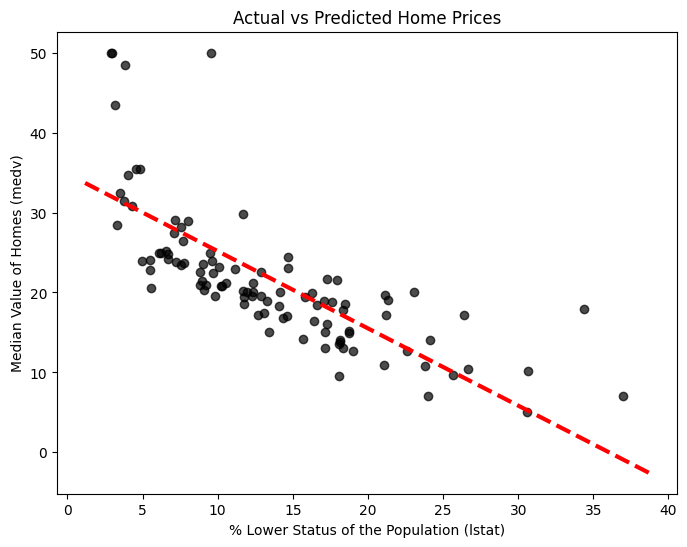

In [18]:
from ISLP import load_data

boston = load_data("Boston")
X_bos = boston[["lstat"]].astype(float)  # explanatory/predictor variable(s)
Y_bos = boston["medv"].astype(float)  # response

X_train_bos, X_test_bos, y_train_bos, y_test_bos = train_test_split(
    X_bos,
    Y_bos,
    test_size=0.2,
    random_state=42,
)

lm = LinearRegression()
lm.fit(X_train_bos, y_train_bos)
y_pred_bos = lm.predict(X_test_bos)
mae = mean_absolute_error(y_test_bos, y_pred_bos)
r2 = r2_score(y_test_bos, y_pred_bos)
print("=== Linear Regression: Boston Housing ===")
print(f"R² Score:              {r2:.4f}")
print(f"Mean Absolute Error:   ${mae:,.0f}")
print("\nCoefficients:")
print(f"  lstat       : {lm.coef_[0]:>10,.2f}")
print(f"  Intercept   : {lm.intercept_:>10,.2f}")

# Let's plot the original data and the fitted line
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    X_test_bos["lstat"], y_test_bos, alpha=0.7, color="black", label="Actual Price"
)
# Grab the x values for the line (we can use the test set's lstat range)
x_lower, x_upper = ax.get_xlim()
y_lower = lm.intercept_ + lm.coef_[0] * x_lower
y_upper = lm.intercept_ + lm.coef_[0] * x_upper
ax.plot([x_lower, x_upper], [y_lower, y_upper], "r--", linewidth=3, label="Fitted Line")
ax.set_xlabel("% Lower Status of the Population (lstat)")
ax.set_ylabel("Median Value of Homes (medv)")
ax.set_title("Actual vs Predicted Home Prices")